In [43]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras import backend as K

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train [shape (60000, 28, 28)] sample patch 
 [[  0  76 246 252 112]
 [  0  85 252 230  25]
 [  0  85 252 223   0]
 [  0  85 252 145   0]
 [  0  86 253 225   0]]


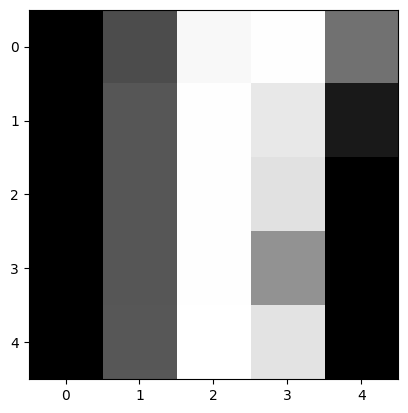

In [45]:
print("x_train [shape %s] sample patch \n" % str(x_train.shape), x_train[1, 15:20, 5:10])
plt.imshow(x_train[1, 15:20, 5:10], cmap='gray')

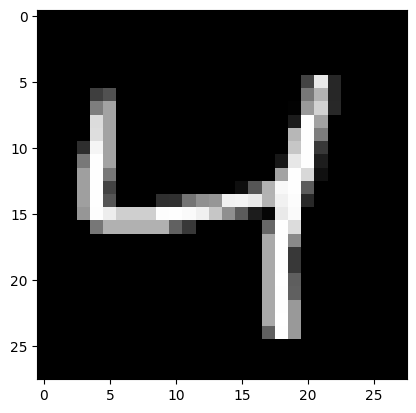

In [46]:
plt.imshow(x_train[2], cmap='gray')
plt.show()

In [47]:
import tensorflow as tf
# Load and preprocess the MNIST dataset
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

x_train = x_train.astype('float32') / 255.0# scaling min max scaler
x_test = x_test.astype('float32') /255.0
#flatten the images (28*28 into 784)
x_train = x_train.reshape(x_train.shape[0], -1)
x_test = x_test.reshape(x_test.shape[0], -1)
#one - hot encoding labels
y_train = tf.keras.utils.to_categorical(y_train, num_classes=10)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=10)

model = tf.keras.Sequential([
    tf.keras.layers.Dense(200, activation = 'relu', input_shape =(784,)),
    tf.keras.layers.Dense(100, activation = 'relu'),
    tf.keras.layers.Dense(60, activation = 'relu'),
    tf.keras.layers.Dense(30, activation = 'relu'),
    tf.keras.layers.Dense(10, activation = 'softmax')
])
model.summary()

C:\Users\NOTEBOOK\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_25 (Dense)                │ (None, 200)            │       157,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 60)             │         6,060 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 30)             │         1,830 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 10)             │           310 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 185,300 (723.83 KB)

 Trainable params: 185,300 (723.83 KB)

 Non-trainable params: 0 (0.00 B)

In [48]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss = 'categorical_crossentropy',
              metrics=['accuracy'])

In [49]:
history = model.fit(x_train, y_train, epochs=10, batch_size=64, validation_split=0.2)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9047 - loss: 0.3157 - val_accuracy: 0.9567 - val_loss: 0.1451
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9653 - loss: 0.1138 - val_accuracy: 0.9638 - val_loss: 0.1139
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9767 - loss: 0.0771 - val_accuracy: 0.9689 - val_loss: 0.1090
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9818 - loss: 0.0583 - val_accuracy: 0.9726 - val_loss: 0.0912
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9856 - loss: 0.0458 - val_accuracy: 0.9741 - val_loss: 0.0924
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9876 - loss: 0.0381 - val_accuracy: 0.9758 - val_loss: 0.0952
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9896 - loss: 0.0326 - val_accuracy: 0.9777 - val_loss: 0.0946
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9908 - loss: 0.0272 - val_accuracy: 0.

In [50]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f'Test accuracy: {test_acc}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9769 - loss: 0.0917
Test accuracy: 0.9768999814987183


In [51]:
import numpy as np
def get_random_indices(total_image, num_image):
    indices = np.random.choice(total_image, num_image, replace=False)
    return indices

In [52]:
predictions = model.predict(x_test)
x_test_images = x_test.reshape(-1, 28, 28)
prediction_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(y_test, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


In [53]:
num_images_to_show = 5
random_indices = get_random_indices(len(x_test), num_images_to_show)
def plot_images(images, labels, predictions):
    for i in range (len(images)):
        plt.subplot(1, 5, i + 1)
        plt.imshow(images[i], cmap='gray')
        plt.title(f'Actual: {labels[i]}, \n Prediction: {predictions[i]}')
        plt.axis('off')
    plt.show()

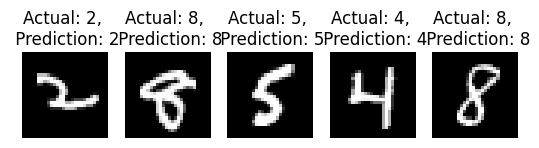

In [54]:
plot_images(x_test_images[random_indices], true_classes[random_indices], prediction_classes[random_indices])

In [ ]:
import tensorflow as tf
from tensorflow.keras.callbacks import TensorBoard

NAME = 'mnist-28-28-v1'
tensorboard = TensorBoard(log_dir='logs/{}'.format(NAME))

# Load and preprocess the MNIST dataset
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()
 
x_train = x_train.astype('float32') / 255.0# scaling min max scaler
x_test = x_test.astype('float32') /255.0

#flatten the images (28*28 into 784)
x_train = x_train.reshape(x_train.shape[0], -1)
x_test = x_test.reshape(x_test.shape[0], -1)

#one - hot encoding labels
y_train = tf.keras.utils.to_categorical(y_train, num_classes=10)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=10)
 
model = tf.keras.Sequential([
    tf.keras.layers.Dense(200, activation = 'relu', input_shape =(784,)),
    tf.keras.layers.Dense(100, activation = 'relu'),
    tf.keras.layers.Dense(60, activation = 'relu'),
    tf.keras.layers.Dense(30, activation = 'relu'),
    tf.keras.layers.Dense(10, activation = 'softmax')
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

historty = model.fit(x_train,y_train, epochs =10, batch_size=64, validation_split=0.2, callbacks=[tensorboard])
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f'Test accuracy: {test_acc}')

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.5960 - loss: 1.1593 - val_accuracy: 0.7752 - val_loss: 0.6951
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8235 - loss: 0.5791 - val_accuracy: 0.8603 - val_loss: 0.4493
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8811 - loss: 0.4031 - val_accuracy: 0.8995 - val_loss: 0.3339
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9071 - loss: 0.3174 - val_accuracy: 0.9183 - val_loss: 0.2790
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9249 - loss: 0.2585 - val_accuracy: 0.9270 - val_loss: 0.2422
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9368 - loss: 0.2166 - val_accuracy: 0.9437 - val_loss: 0.1941
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9448 - loss: 0.1868 - val_accuracy: 0.9479 - val_loss: 0.1824
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9520 - loss: 0.1644 - val_accuracy: 0.

In [ ]:
!tensorboard --logdir = logs --port = 6006

C:\Users\NOTEBOOK\AppData\Roaming\Python\Python312\site-packages\tensorboard\default.py:30: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
2026-04-08 21:34:03.468901: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-08 21:34:10.328764: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
usage: tensorboard [-h] [--helpfull] [--logdir PATH] [-